# IPL Data Analysis

This notebook answers all 23 questions on the IPL `matches.csv` and `deliveries.csv` datasets.

DATA FIX- The 7 matches played at the *Dubai International Cricket Stadium* (2014 season) have a blank value in the `city` column in the raw CSV. This is fixed in the data-cleaning cell below by filling `city = 'Dubai'` for those rows, based on the `venue` column. Every question after that cell uses the cleaned `matches` DataFrame.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading & Cleaning

In [4]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Missing city values before fix:", matches['city'].isna().sum())

dubai_mask = matches['venue'] == 'Dubai International Cricket Stadium'
matches.loc[dubai_mask, 'city'] = matches.loc[dubai_mask, 'city'].fillna('Dubai')

print("Missing city values after fix: ", matches['city'].isna().sum())
matches.loc[dubai_mask, ['id', 'season', 'city', 'venue']]

Missing city values before fix: 7
Missing city values after fix:  0


,id,season,city,venue
461,462,2014,Dubai,Dubai International Cricket Stadium
462,463,2014,Dubai,Dubai International Cricket Stadium
466,467,2014,Dubai,Dubai International Cricket Stadium
468,469,2014,Dubai,Dubai International Cricket Stadium
469,470,2014,Dubai,Dubai International Cricket Stadium
474,475,2014,Dubai,Dubai International Cricket Stadium
476,477,2014,Dubai,Dubai International Cricket Stadium


## Question 1: Count the total number of matches conducted in 2008.

In [5]:
matches_2008 = matches[matches['season'] == 2008].shape[0]

print(f"Total number of matches conducted in 2008: {matches_2008}")

Total number of matches conducted in 2008: 58


## Question 2: Find the cities where the maximum and minimum number of matches were conducted.

In [6]:
city_count = matches['city'].value_counts()
max, max_count = city_count.idxmax(), city_count.max()
min, min_count = city_count.idxmin(), city_count.min()

print(f"City with maximum matches: {max} ({max_count} matches)")
print(f"City with minimum matches: {min} ({min_count} matches)")

City with maximum matches: Mumbai (101 matches)
City with minimum matches: Bloemfontein (2 matches)


## Question 3: Find total count of matches city-wise.

In [7]:
city_total = matches['city'].value_counts().to_dict()

for city, count in city_total.items():
    print(f"{city}: {count} matches")

Mumbai: 101 matches
Kolkata: 77 matches
Delhi: 74 matches
Bangalore: 66 matches
Hyderabad: 64 matches
Chennai: 57 matches
Jaipur: 47 matches
Chandigarh: 46 matches
Pune: 38 matches
Durban: 15 matches
Bengaluru: 14 matches
Visakhapatnam: 13 matches
Centurion: 12 matches
Ahmedabad: 12 matches
Rajkot: 10 matches
Mohali: 10 matches
Indore: 9 matches
Dharamsala: 9 matches
Johannesburg: 8 matches
Cape Town: 7 matches
Port Elizabeth: 7 matches
Cuttack: 7 matches
Ranchi: 7 matches
Abu Dhabi: 7 matches
Dubai: 7 matches
Raipur: 6 matches
Sharjah: 6 matches
Kochi: 5 matches
Kanpur: 4 matches
East London: 3 matches
Kimberley: 3 matches
Nagpur: 3 matches
Bloemfontein: 2 matches


## Question 4: Tally the toss decisions each team has taken.

In [8]:
toss_tally = matches.groupby(['toss_winner', 'toss_decision']).size()

print(f"Toss Decisions Tally: \n{toss_tally}")

Toss Decisions Tally: 
toss_winner                  toss_decision
Chennai Super Kings          bat              48
                             field            41
Deccan Chargers              bat              24
                             field            19
Delhi Capitals               bat               2
                             field             8
Delhi Daredevils             bat              29
                             field            51
Gujarat Lions                bat               1
                             field            14
Kings XI Punjab              bat              26
                             field            55
Kochi Tuskers Kerala         bat               3
                             field             5
Kolkata Knight Riders        bat              30
                             field            62
Mumbai Indians               bat              44
                             field            54
Pune Warriors                bat              11
   

## Question 5: Count the total number of normal and tied matches.

In [9]:
match_results = matches['result'].value_counts()
normal_matches = match_results.get('normal', 0)
tied_matches = match_results.get('tie', 0)

print(f"Total number of normal matches: {normal_matches}")
print(f"Total number of tied matches: {tied_matches}")

Total number of normal matches: 743
Total number of tied matches: 9


## Question 6: Find the teams where the result was a tie.

In [10]:
tied_matches = matches[matches['result'] == 'tie']
tied_teams = sorted(list(set(tied_matches['team1']).union(set(tied_matches['team2']))))

print(f"Teams where the result was a tie: {', '.join(tied_teams)}")

Teams where the result was a tie: Chennai Super Kings, Delhi Capitals, Delhi Daredevils, Gujarat Lions, Kings XI Punjab, Kolkata Knight Riders, Mumbai Indians, Rajasthan Royals, Royal Challengers Bangalore, Sunrisers Hyderabad


## Question 7: Find the team which won the match by the highest and lowest number of runs.

In [11]:
max_run_win = matches.loc[matches['win_by_runs'].idxmax()]

runs_gt_zero = matches[matches['win_by_runs'] > 0]
min_run_wins = runs_gt_zero[runs_gt_zero['win_by_runs'] == runs_gt_zero['win_by_runs'].min()]

print(f"\nMatch with the highest run win: {max_run_win['team1']} vs {max_run_win['team2']} - Winner: {max_run_win['winner']} by {max_run_win['win_by_runs']} runs\n")
print("Matches with the lowest run win:")
print(min_run_wins[['team1', 'team2', 'winner', 'win_by_runs']].to_string(index=False))


Match with the highest run win: Mumbai Indians vs Delhi Daredevils - Winner: Mumbai Indians by 146 runs

Matches with the lowest run win:
                      team1                  team2                      winner  win_by_runs
             Mumbai Indians Rising Pune Supergiant              Mumbai Indians            1
            Kings XI Punjab         Mumbai Indians             Kings XI Punjab            1
            Kings XI Punjab        Deccan Chargers             Kings XI Punjab            1
           Delhi Daredevils       Rajasthan Royals            Delhi Daredevils            1
             Mumbai Indians          Pune Warriors              Mumbai Indians            1
        Chennai Super Kings       Delhi Daredevils         Chennai Super Kings            1
              Gujarat Lions       Delhi Daredevils               Gujarat Lions            1
Royal Challengers Bangalore        Kings XI Punjab Royal Challengers Bangalore            1
Royal Challengers Bangalore    Ch

## Question 8: Calculate mean, median and standard deviation of ‘win_by_runs’

In [12]:
mean_all, median_all, std_all = matches['win_by_runs'].mean(), matches['win_by_runs'].median(), matches['win_by_runs'].std()


print(f"Mean: {mean_all:.2f}")
print(f"Median: {median_all:.2f}")
print(f"Standard Deviation: {std_all:.2f}\n")



print("For matches where win_by_runs > 0")
runs_gt_zero = matches[matches['win_by_runs'] > 0]
mean_gt0, median_gt0, std_gt0 = runs_gt_zero['win_by_runs'].mean(), runs_gt_zero['win_by_runs'].median(), runs_gt_zero['win_by_runs'].std()

print(f"Mean: {mean_gt0:.2f}")
print(f"Median: {median_gt0:.2f}")
print(f"Standard Deviation: {std_gt0:.2f}")

Mean: 13.28
Median: 0.00
Standard Deviation: 23.47

For matches where win_by_runs > 0
Mean: 29.80
Median: 22.00
Standard Deviation: 27.28


## Question 9: Find the venue where the team won by the highest and lowest number of runs.

In [13]:
max_run_win = matches.loc[matches['win_by_runs'].idxmax()]
run_wins = matches[matches['win_by_runs'] > 0]
min_run_wins = run_wins[run_wins['win_by_runs'] == run_wins['win_by_runs'].min()]

venue_max = max_run_win['venue']
venues_min = min_run_wins['venue'].unique().tolist()

print(f"\nVenue where the team won by the highest number of runs: {venue_max}\n")
print("Venues where the team won by the lowest number of runs:")
for venue in venues_min:
    print(venue)


Venue where the team won by the highest number of runs: Feroz Shah Kotla

Venues where the team won by the lowest number of runs:
Rajiv Gandhi International Stadium, Uppal
Wankhede Stadium
New Wanderers Stadium
Feroz Shah Kotla
Subrata Roy Sahara Stadium
MA Chidambaram Stadium, Chepauk
Punjab Cricket Association IS Bindra Stadium, Mohali
M. Chinnaswamy Stadium
Rajiv Gandhi Intl. Cricket Stadium


## Question 10: Find the players who have won ‘Player of the Match’ more than 3 times.

In [14]:
potm_counts = matches['player_of_match'].value_counts()
potm_gt_3 = potm_counts[potm_counts > 3]

print("Players who have won 'Player of the Match' more than 3 times:")
for player, count in potm_gt_3.items():
    print(f"{player}: {count} times")

Players who have won 'Player of the Match' more than 3 times:
CH Gayle: 21 times
AB de Villiers: 20 times
MS Dhoni: 17 times
DA Warner: 17 times
RG Sharma: 17 times
YK Pathan: 16 times
SR Watson: 15 times
SK Raina: 14 times
G Gambhir: 13 times
MEK Hussey: 12 times
V Kohli: 12 times
AM Rahane: 12 times
DR Smith: 11 times
V Sehwag: 11 times
A Mishra: 11 times
AD Russell: 11 times
KA Pollard: 10 times
JH Kallis: 10 times
SP Narine: 9 times
AT Rayudu: 9 times
SE Marsh: 9 times
SR Tendulkar: 8 times
Harbhajan Singh: 8 times
RA Jadeja: 8 times
UT Yadav: 8 times
Rashid Khan: 7 times
RV Uthappa: 7 times
AC Gilchrist: 7 times
RR Pant: 6 times
S Dhawan: 6 times
A Nehra: 6 times
BJ Hodge: 6 times
SL Malinga: 6 times
M Vijay: 6 times
HH Pandya: 6 times
Yuvraj Singh: 5 times
SPD Smith: 5 times
GJ Maxwell: 5 times
SV Samson: 5 times
JJ Bumrah: 5 times
B Kumar: 5 times
JC Buttler: 5 times
Sandeep Sharma: 5 times
JD Unadkat: 5 times
BB McCullum: 5 times
KC Sangakkara: 5 times
SC Ganguly: 5 times
DPMD 

## Question 11: Find all deliveries where the batsman scored a six.

In [15]:
sixes = deliveries[deliveries['batsman_runs'] == 6]
sixes_count = len(sixes)

print(f"Total number of deliveries where the batsman scored a six: {sixes_count}\n")

Total number of deliveries where the batsman scored a six: 8170



## Question 12: Compute the average runs scored in matches in all the venues.

In [16]:
match_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()

match_venue = pd.merge(match_runs, matches[['id', 'venue']], left_on='match_id', right_on='id')

venue_stats = match_venue.groupby('venue')['total_runs'].agg(
    avg_runs_per_match='mean',
    matches_count='count',
    total_runs='sum'
).sort_values(by='avg_runs_per_match', ascending=False)

print("Average runs scored in matches in all the venues:\n")
for venue, stats in venue_stats.iterrows():
    print(f"Venue: {venue}")
    print(f"Average Runs per Match: {stats['avg_runs_per_match']:.2f}")
    print(f"Total Matches: {stats['matches_count']}")
    print(f"Total Runs: {stats['total_runs']}\n")

Average runs scored in matches in all the venues:

Venue: IS Bindra Stadium
Average Runs per Match: 354.71
Total Matches: 7.0
Total Runs: 2483.0

Venue: Brabourne Stadium
Average Runs per Match: 349.27
Total Matches: 11.0
Total Runs: 3842.0

Venue: M. Chinnaswamy Stadium
Average Runs per Match: 334.71
Total Matches: 7.0
Total Runs: 2343.0

Venue: Punjab Cricket Association IS Bindra Stadium, Mohali
Average Runs per Match: 334.36
Total Matches: 14.0
Total Runs: 4681.0

Venue: Saurashtra Cricket Association Stadium
Average Runs per Match: 333.30
Total Matches: 10.0
Total Runs: 3333.0

Venue: ACA-VDCA Stadium
Average Runs per Match: 329.00
Total Matches: 2.0
Total Runs: 658.0

Venue: Rajiv Gandhi Intl. Cricket Stadium
Average Runs per Match: 327.62
Total Matches: 8.0
Total Runs: 2621.0

Venue: Maharashtra Cricket Association Stadium
Average Runs per Match: 327.19
Total Matches: 21.0
Total Runs: 6871.0

Venue: Barabati Stadium
Average Runs per Match: 325.43
Total Matches: 7.0
Total Runs: 2

## Question 13: Find the umpires who umpired the maximum number of times.

In [17]:
all_umpires = pd.concat([matches['umpire1'], matches['umpire2'], matches['umpire3']])

umpire_counts = all_umpires.value_counts()

max_matches = umpire_counts.max()
most_frequent_umpires = umpire_counts[umpire_counts == max_matches]

print(f"Maximum Matches Umpired: {max_matches}")
print(most_frequent_umpires.to_string(header=False))

Maximum Matches Umpired: 114
S Ravi    114


## Question 14: Find the total number of matches played in each season.

In [18]:
matches_per_season = matches['season'].value_counts().sort_index()

print("Total number of matches played in each season:\n")
for season, count in matches_per_season.items():
    print(f"Season: {season}, Matches Played: {count}")

Total number of matches played in each season:

Season: 2008, Matches Played: 58
Season: 2009, Matches Played: 57
Season: 2010, Matches Played: 60
Season: 2011, Matches Played: 73
Season: 2012, Matches Played: 74
Season: 2013, Matches Played: 76
Season: 2014, Matches Played: 60
Season: 2015, Matches Played: 59
Season: 2016, Matches Played: 60
Season: 2017, Matches Played: 59
Season: 2018, Matches Played: 60
Season: 2019, Matches Played: 60


## Question 15: Find total runs scored in each season.

In [19]:
deliv_matches = pd.merge(deliveries, matches[['id', 'season']], left_on='match_id', right_on='id')
runs_per_season = deliv_matches.groupby('season')['total_runs'].sum().sort_index()

print("Total runs scored in each season:\n")
for season, total_runs in runs_per_season.items():
    print(f"Season: {season}, Total Runs: {total_runs}")

Total runs scored in each season:

Season: 2008, Total Runs: 17937
Season: 2009, Total Runs: 16353
Season: 2010, Total Runs: 18883
Season: 2011, Total Runs: 21154
Season: 2012, Total Runs: 22453
Season: 2013, Total Runs: 22602
Season: 2014, Total Runs: 18931
Season: 2015, Total Runs: 18353
Season: 2016, Total Runs: 18862
Season: 2017, Total Runs: 18786
Season: 2018, Total Runs: 20706
Season: 2019, Total Runs: 20270


## Question 16: Calculate total number of runs scored by each batsman and display top 10.

In [20]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

print("Top 10 Batsmen by Total Runs Scored:\n")
for batsman, total_runs in top_batsmen.items():
    print(f"Batsman: {batsman}, Total Runs: {total_runs}")

Top 10 Batsmen by Total Runs Scored:

Batsman: V Kohli, Total Runs: 5434
Batsman: SK Raina, Total Runs: 5415
Batsman: RG Sharma, Total Runs: 4914
Batsman: DA Warner, Total Runs: 4741
Batsman: S Dhawan, Total Runs: 4632
Batsman: CH Gayle, Total Runs: 4560
Batsman: MS Dhoni, Total Runs: 4477
Batsman: RV Uthappa, Total Runs: 4446
Batsman: AB de Villiers, Total Runs: 4428
Batsman: G Gambhir, Total Runs: 4223


## Question 17: Compute the total number of wickets taken by each bowler.

In [21]:
bowler_dismissals = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

bowler_wickets_df = deliveries[deliveries['dismissal_kind'].isin(bowler_dismissals)]
top_bowlers = bowler_wickets_df.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False)

print("\nTotal Wickets Taken by Each Bowler:\n")
for bowler, total_wickets in top_bowlers.items():
    print(f"Bowler: {bowler}, Total Wickets: {total_wickets}")


Total Wickets Taken by Each Bowler:

Bowler: SL Malinga, Total Wickets: 170
Bowler: A Mishra, Total Wickets: 156
Bowler: Harbhajan Singh, Total Wickets: 150
Bowler: PP Chawla, Total Wickets: 149
Bowler: DJ Bravo, Total Wickets: 147
Bowler: B Kumar, Total Wickets: 133
Bowler: R Ashwin, Total Wickets: 125
Bowler: SP Narine, Total Wickets: 122
Bowler: UT Yadav, Total Wickets: 119
Bowler: RA Jadeja, Total Wickets: 108
Bowler: A Nehra, Total Wickets: 106
Bowler: R Vinay Kumar, Total Wickets: 105
Bowler: Z Khan, Total Wickets: 102
Bowler: YS Chahal, Total Wickets: 100
Bowler: DW Steyn, Total Wickets: 96
Bowler: SR Watson, Total Wickets: 92
Bowler: MM Sharma, Total Wickets: 91
Bowler: P Kumar, Total Wickets: 90
Bowler: RP Singh, Total Wickets: 90
Bowler: PP Ojha, Total Wickets: 89
Bowler: DS Kulkarni, Total Wickets: 86
Bowler: JA Morkel, Total Wickets: 85
Bowler: Sandeep Sharma, Total Wickets: 83
Bowler: JJ Bumrah, Total Wickets: 82
Bowler: IK Pathan, Total Wickets: 80
Bowler: Imran Tahir, T

## Question 18: Compute batting averages and display top 10.

In [22]:
total_runs = deliveries.groupby('batsman')['batsman_runs'].sum()
dismissals = deliveries[deliveries['player_dismissed'].notna()]
total_outs = dismissals.groupby('player_dismissed').size()
batting_average = total_runs / total_outs
batting_average = batting_average
top_10_average = batting_average.sort_values(ascending=False).head(10)

print(f"Top 10 Batting Averages:")
for batsman, average in top_10_average.items():
    print(f"Batsman: {batsman}, Batting Average: {average:.2f}")

Top 10 Batting Averages:


Batsman: J Bairstow, Batting Average: 58.50
Batsman: MN van Wyk, Batting Average: 55.67
Batsman: AC Voges, Batting Average: 45.25
Batsman: HM Amla, Batting Average: 44.38
Batsman: Iqbal Abdulla, Batting Average: 44.00
Batsman: DA Warner, Batting Average: 43.10
Batsman: KL Rahul, Batting Average: 42.83
Batsman: MS Dhoni, Batting Average: 42.64
Batsman: CH Gayle, Batting Average: 41.83
Batsman: PD Collingwood, Batting Average: 40.60


## Question 19: Visualize toss decisions across all seasons.

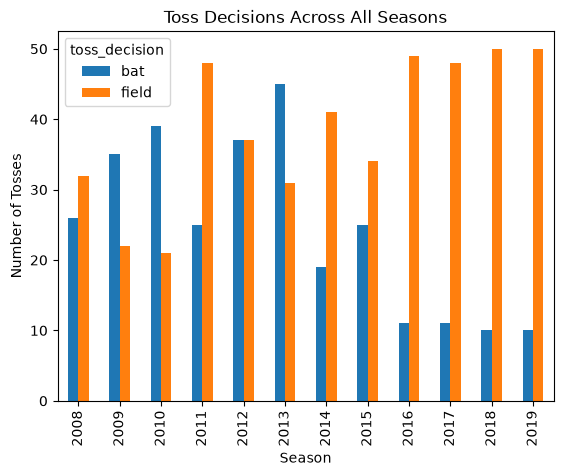

Showing the chart for toss decisions now.


In [23]:
toss_data = matches.groupby(['season', 'toss_decision']).size().unstack()
toss_data.plot(kind='bar')
plt.title('Toss Decisions Across All Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Tosses')
plt.show()
print("Showing the chart for toss decisions now.")

## Question 20: Visualize Total Matches vs Winning Matches vs Win Rate for all teams.

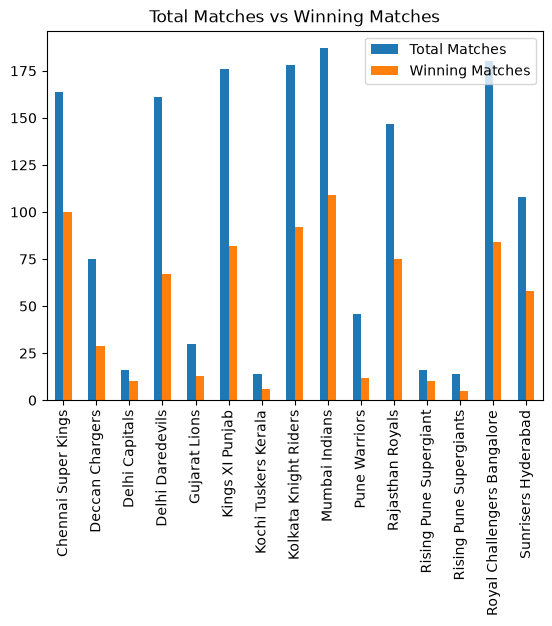

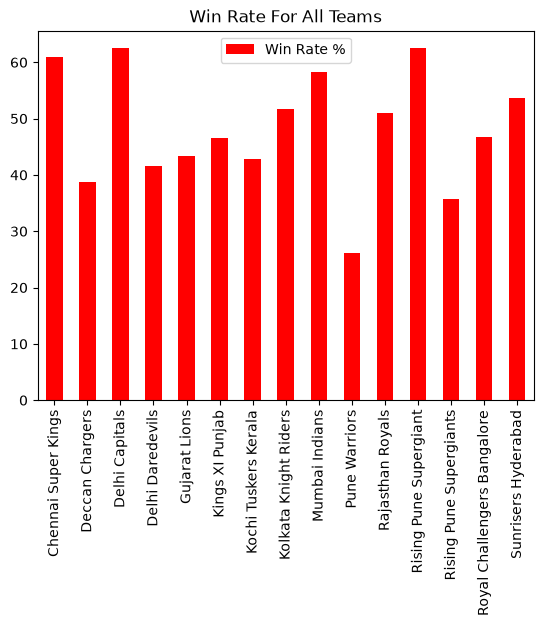

                             Total Matches  Winning Matches  Win Rate %
Chennai Super Kings                    164              100   60.975610
Deccan Chargers                         75               29   38.666667
Delhi Capitals                          16               10   62.500000
Delhi Daredevils                       161               67   41.614907
Gujarat Lions                           30               13   43.333333
Kings XI Punjab                        176               82   46.590909
Kochi Tuskers Kerala                    14                6   42.857143
Kolkata Knight Riders                  178               92   51.685393
Mumbai Indians                         187              109   58.288770
Pune Warriors                           46               12   26.086957
Rajasthan Royals                       147               75   51.020408
Rising Pune Supergiant                  16               10   62.500000
Rising Pune Supergiants                 14                5   35

In [24]:
team1_count = matches['team1'].value_counts()
team2_count = matches['team2'].value_counts()
total_matches = team1_count + team2_count
winning_matches = matches['winner'].value_counts()
win_rate = (winning_matches / total_matches) * 100

data = pd.DataFrame({'Total Matches': total_matches, 'Winning Matches': winning_matches, 'Win Rate %': win_rate})
data.plot(kind='bar', y=['Total Matches', 'Winning Matches'])
plt.title('Total Matches vs Winning Matches')
plt.show()

data.plot(kind='bar', y='Win Rate %', color='red')
plt.title('Win Rate For All Teams')
plt.show()
print(data)

## Question 21: Find the distribution of the teams who won the matches.

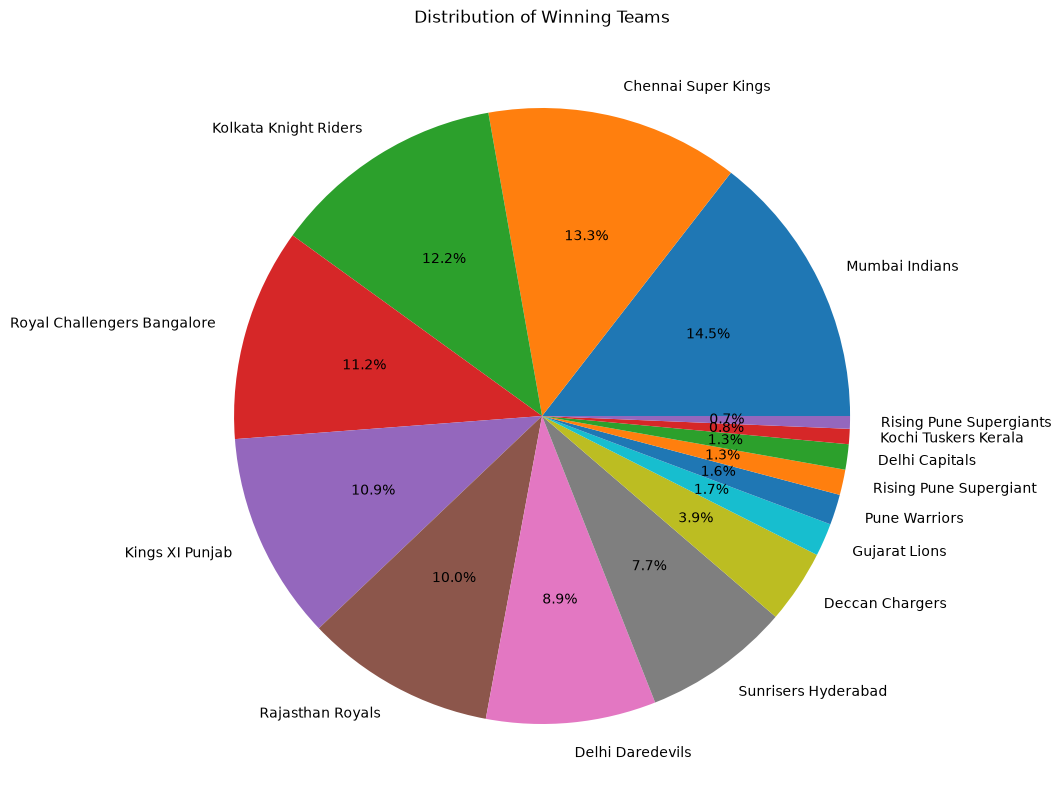

Distribution of match winners:
winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [25]:
winner_distribution = matches['winner'].value_counts()
winner_distribution.plot(kind='pie', autopct='%1.1f%%', figsize=(10, 10))
plt.title('Distribution of Winning Teams')
plt.ylabel('')
plt.show()
print("Distribution of match winners:")
print(winner_distribution)

## Question 22: Visualize the toss outcomes of all teams.

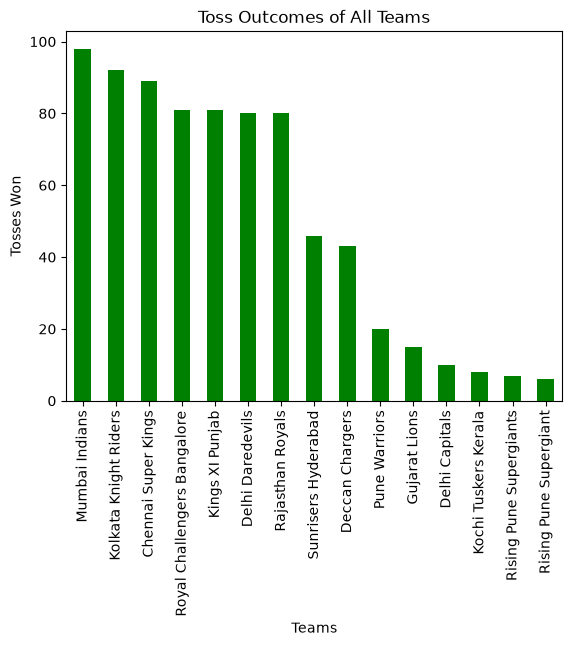

Here are the toss outcomes for all teams:
toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Royal Challengers Bangalore    81
Kings XI Punjab                81
Delhi Daredevils               80
Rajasthan Royals               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Delhi Capitals                 10
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64


In [26]:
toss_winners = matches['toss_winner'].value_counts()
toss_winners.plot(kind='bar', color='green')
plt.title('Toss Outcomes of All Teams')
plt.xlabel('Teams')
plt.ylabel('Tosses Won')
plt.show()
print("Here are the toss outcomes for all teams:")
print(toss_winners)

## Question 23: Visualize the top 5 teams with the most wins across all seasons.

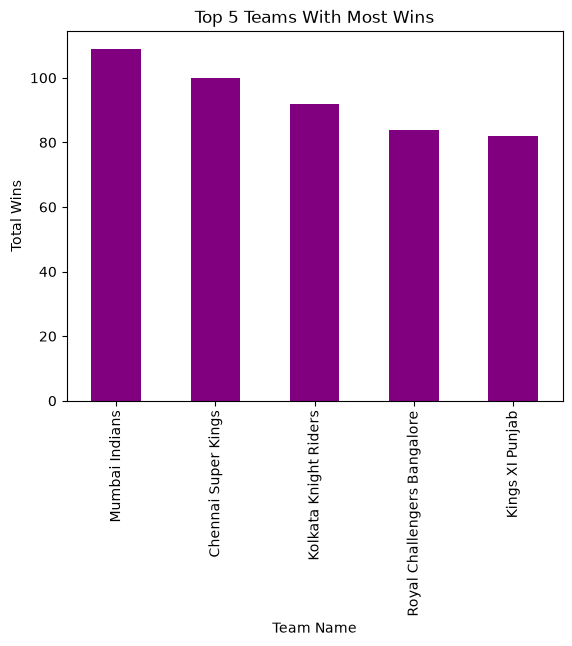

Top 5 teams list:
winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Name: count, dtype: int64


In [27]:
team_wins = matches['winner'].value_counts()
top_5_teams = team_wins.head(5)
top_5_teams.plot(kind='bar', color='purple')
plt.title('Top 5 Teams With Most Wins')
plt.xlabel('Team Name')
plt.ylabel('Total Wins')
plt.show()
print("Top 5 teams list:")
print(top_5_teams)